# Project 1: Data Cleaning & Preparation

**DecodeLabs Data Analytics Industrial Training | Batch 2026**

This notebook turns a raw e-commerce workbook into a validated, analysis-ready DataFrame.
It follows the official Project 1 brief and keeps the complete workflow in one place:

- identify missing and null values;
- detect and remove duplicates;
- correct date, numeric, identifier, and text formats;
- prove zero duplicate IDs;
- prove zero incorrectly formatted dates.

The notebook does not generate a separate cleaned workbook. The source remains unchanged,
while `clean_df` contains the cleaned dataset during execution.

## 1. Business and Data Context

Reliable analysis starts with reliable data. Duplicate identifiers can inflate revenue and order
counts, invalid dates can corrupt trends, missing values can bias summaries, and inconsistent formats
can split logically identical categories.

The dataset represents e-commerce orders with customer, product, quantity, price, fulfillment,
payment, coupon, referral, tracking, and shipping information.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "navy": "#17324D",
    "blue": "#2878B5",
    "teal": "#2A9D8F",
    "gold": "#E9C46A",
    "red": "#D95D5D",
    "gray": "#6B7280",
}
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "figure.dpi": 110,
})

candidates = [
    Path("Dataset_for_Data_Analytics.xlsx"),
    Path("Project_01") / "Dataset_for_Data_Analytics.xlsx",
]
DATA_PATH = next((path for path in candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset_for_Data_Analytics.xlsx was not found.")

raw_df = pd.read_excel(DATA_PATH)
print(f"Loaded {len(raw_df):,} rows and {raw_df.shape[1]} columns from {DATA_PATH}")

Loaded 1,200 rows and 14 columns from Dataset_for_Data_Analytics.xlsx


## 2. Data Dictionary

The dictionary defines each field before any cleaning decision is made.

In [2]:
data_dictionary = pd.DataFrame([
    ("OrderID", "Identifier", "Unique order identifier; expected pattern ORD followed by six digits."),
    ("Date", "Date", "Date on which the order was recorded."),
    ("CustomerID", "Identifier", "Customer identifier; expected pattern C followed by five digits."),
    ("Product", "Category", "Product purchased in the order."),
    ("Quantity", "Integer", "Number of product units ordered."),
    ("UnitPrice", "Decimal", "Price charged per unit."),
    ("ShippingAddress", "Text", "Destination address provided for the order."),
    ("PaymentMethod", "Category", "Payment method selected by the customer."),
    ("OrderStatus", "Category", "Current fulfillment or resolution status."),
    ("TrackingNumber", "Identifier", "Tracking identifier; expected pattern TRK followed by eight digits."),
    ("ItemsInCart", "Integer", "Number of items recorded in the cart."),
    ("CouponCode", "Optional category", "Promotion code; blank means no coupon was used."),
    ("ReferralSource", "Category", "Channel through which the customer was referred."),
    ("TotalPrice", "Decimal", "Order total, expected to equal Quantity multiplied by UnitPrice."),
], columns=["Column", "Business Type", "Description"])
display(data_dictionary)

,Column,Business Type,Description
0,OrderID,Identifier,Unique order identifier; expected pattern ORD ...
1,Date,Date,Date on which the order was recorded.
2,CustomerID,Identifier,Customer identifier; expected pattern C follow...
3,Product,Category,Product purchased in the order.
4,Quantity,Integer,Number of product units ordered.
5,UnitPrice,Decimal,Price charged per unit.
6,ShippingAddress,Text,Destination address provided for the order.
7,PaymentMethod,Category,Payment method selected by the customer.
8,OrderStatus,Category,Current fulfillment or resolution status.
9,TrackingNumber,Identifier,Tracking identifier; expected pattern TRK foll...


## 3. Raw Data Audit

The audit preserves the original DataFrame and measures its condition before applying transformations.

In [3]:
print(f"Raw shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
display(raw_df.head())

schema_audit = pd.DataFrame({
    "Data Type": raw_df.dtypes.astype(str),
    "Non-Null Count": raw_df.notna().sum(),
    "Missing Count": raw_df.isna().sum(),
    "Unique Values": raw_df.nunique(dropna=True),
})
display(schema_audit)

Raw shape: 1,200 rows × 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.10"
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.40"
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.04"


,Data Type,Non-Null Count,Missing Count,Unique Values
OrderID,object,1200,0,1200
Date,datetime64[ns],1200,0,671
CustomerID,object,1200,0,1189
Product,object,1200,0,7
Quantity,int64,1200,0,5
UnitPrice,float64,1200,0,1193
ShippingAddress,object,1200,0,655
PaymentMethod,object,1200,0,5
OrderStatus,object,1200,0,5
TrackingNumber,object,1200,0,1200


In [4]:
missing_before = pd.DataFrame({
    "Missing Count": raw_df.isna().sum(),
    "Missing Percentage": raw_df.isna().mean().mul(100),
}).sort_values(["Missing Count", "Missing Percentage"], ascending=False)
display(missing_before)

total_missing_before = int(raw_df.isna().sum().sum())
coupon_missing_before = int(raw_df["CouponCode"].isna().sum())
overall_completeness_before = 100 * raw_df.notna().sum().sum() / raw_df.size

print(f"Total missing cells: {total_missing_before:,}")
print(f"Blank CouponCode values: {coupon_missing_before:,}")
print(f"Overall cell completeness: {overall_completeness_before:.2f}%")
print(
    "Interpretation: CouponCode is optional. Its blanks represent orders where no coupon was used, "
    "so they require a business label rather than row deletion or statistical imputation."
)

,Missing Count,Missing Percentage
CouponCode,309,25.75
OrderID,0,0.00
Date,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
PaymentMethod,0,0.00
OrderStatus,0,0.00


Total missing cells: 309
Blank CouponCode values: 309
Overall cell completeness: 98.16%
Interpretation: CouponCode is optional. Its blanks represent orders where no coupon was used, so they require a business label rather than row deletion or statistical imputation.


In [5]:
duplicate_audit = pd.DataFrame({
    "Check": [
        "Complete duplicate rows",
        "Duplicate OrderID values",
        "Duplicate TrackingNumber values",
    ],
    "Issue Count": [
        int(raw_df.duplicated().sum()),
        int(raw_df["OrderID"].duplicated().sum()),
        int(raw_df["TrackingNumber"].duplicated().sum()),
    ],
})
display(duplicate_audit)

parsed_dates_before = pd.to_datetime(raw_df["Date"], errors="coerce")
invalid_dates_before = int(parsed_dates_before.isna().sum())
print(f"Incorrectly formatted or unparseable dates before cleaning: {invalid_dates_before}")
print(f"Observed date range: {parsed_dates_before.min():%Y-%m-%d} to {parsed_dates_before.max():%Y-%m-%d}")

,Check,Issue Count
0,Complete duplicate rows,0
1,Duplicate OrderID values,0
2,Duplicate TrackingNumber values,0


Incorrectly formatted or unparseable dates before cleaning: 0
Observed date range: 2023-01-01 to 2025-06-30


In [6]:
numeric_columns = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
raw_calculated_total = raw_df["Quantity"] * raw_df["UnitPrice"]

raw_rule_audit = pd.DataFrame([
    ("Non-positive Quantity", int((raw_df["Quantity"] <= 0).sum())),
    ("Non-positive UnitPrice", int((raw_df["UnitPrice"] <= 0).sum())),
    ("Non-positive ItemsInCart", int((raw_df["ItemsInCart"] <= 0).sum())),
    ("Non-positive TotalPrice", int((raw_df["TotalPrice"] <= 0).sum())),
    (
        "TotalPrice arithmetic mismatch",
        int((~np.isclose(raw_df["TotalPrice"], raw_calculated_total, atol=0.01)).sum()),
    ),
    (
        "Non-integer Quantity",
        int((pd.to_numeric(raw_df["Quantity"], errors="coerce") % 1 != 0).sum()),
    ),
    (
        "Non-integer ItemsInCart",
        int((pd.to_numeric(raw_df["ItemsInCart"], errors="coerce") % 1 != 0).sum()),
    ),
], columns=["Validation Rule", "Issue Count"])
display(raw_rule_audit)

,Validation Rule,Issue Count
0,Non-positive Quantity,0
1,Non-positive UnitPrice,0
2,Non-positive ItemsInCart,0
3,Non-positive TotalPrice,0
4,TotalPrice arithmetic mismatch,0
5,Non-integer Quantity,0
6,Non-integer ItemsInCart,0


## 4. Missing-Value Treatment

`CouponCode` is the only incomplete field. Blank values are standardized to `NO_COUPON` because:

- the field is optional;
- absence has direct business meaning;
- dropping these rows would discard valid orders;
- mode imputation would falsely claim that a promotion was used.

In [7]:
clean_df = raw_df.copy(deep=True)
clean_df["CouponCode"] = clean_df["CouponCode"].fillna("NO_COUPON")

missing_after_treatment = clean_df.isna().sum()
print(f"Missing cells before treatment: {total_missing_before:,}")
print(f"Missing cells after treatment: {int(missing_after_treatment.sum()):,}")
display(
    clean_df["CouponCode"]
    .value_counts(dropna=False)
    .rename_axis("CouponCode")
    .to_frame("Orders")
)

Missing cells before treatment: 309
Missing cells after treatment: 0


,Orders
CouponCode,
FREESHIP,313
NO_COUPON,309
WINTER15,292
SAVE10,286


## 5. Duplicate Detection and Removal

Deduplication is implemented defensively in two stages:

1. remove complete duplicate rows;
2. enforce one record per `OrderID`, keeping the first occurrence.

The audit found no duplicates, so no records should be removed. The row-count reconciliation below
makes that outcome explicit.

In [8]:
rows_before_deduplication = len(clean_df)
complete_duplicates_found = int(clean_df.duplicated().sum())
duplicate_order_ids_found = int(clean_df["OrderID"].duplicated(keep="first").sum())

clean_df = clean_df.drop_duplicates().copy()
clean_df = clean_df.drop_duplicates(subset=["OrderID"], keep="first").copy()
clean_df = clean_df.reset_index(drop=True)

rows_after_deduplication = len(clean_df)
rows_removed = rows_before_deduplication - rows_after_deduplication

deduplication_report = pd.DataFrame({
    "Metric": [
        "Rows before deduplication",
        "Complete duplicates found",
        "Duplicate OrderIDs found",
        "Rows removed",
        "Rows after deduplication",
    ],
    "Result": [
        rows_before_deduplication,
        complete_duplicates_found,
        duplicate_order_ids_found,
        rows_removed,
        rows_after_deduplication,
    ],
})
display(deduplication_report)

,Metric,Result
0,Rows before deduplication,1200
1,Complete duplicates found,0
2,Duplicate OrderIDs found,0
3,Rows removed,0
4,Rows after deduplication,1200


## 6. Format Standardization

Formatting is normalized even when the current values are already compliant. This makes the pipeline
reusable if future versions of the workbook contain inconsistent casing, whitespace, or types.

In [9]:
# Dates remain true datetime values for reliable filtering, grouping, and validation.
clean_df["Date"] = pd.to_datetime(clean_df["Date"], errors="coerce")

identifier_columns = ["OrderID", "CustomerID", "TrackingNumber"]
categorical_columns = ["Product", "PaymentMethod", "OrderStatus", "ReferralSource"]
free_text_columns = ["ShippingAddress"]

for column in identifier_columns:
    clean_df[column] = clean_df[column].astype("string").str.strip().str.upper()

for column in categorical_columns:
    clean_df[column] = clean_df[column].astype("string").str.strip().str.title()

for column in free_text_columns:
    clean_df[column] = clean_df[column].astype("string").str.strip()

clean_df["CouponCode"] = clean_df["CouponCode"].astype("string").str.strip().str.upper()

clean_df["Quantity"] = pd.to_numeric(clean_df["Quantity"], errors="coerce").astype("Int64")
clean_df["ItemsInCart"] = pd.to_numeric(clean_df["ItemsInCart"], errors="coerce").astype("Int64")
clean_df["UnitPrice"] = pd.to_numeric(clean_df["UnitPrice"], errors="coerce").round(2)
clean_df["TotalPrice"] = pd.to_numeric(clean_df["TotalPrice"], errors="coerce").round(2)

display(pd.DataFrame({
    "Clean Data Type": clean_df.dtypes.astype(str),
    "Missing After Cleaning": clean_df.isna().sum(),
}))

,Clean Data Type,Missing After Cleaning
OrderID,string,0
Date,datetime64[ns],0
CustomerID,string,0
Product,string,0
Quantity,Int64,0
UnitPrice,float64,0
ShippingAddress,string,0
PaymentMethod,string,0
OrderStatus,string,0
TrackingNumber,string,0


## 7. Data Validation

The validation layer checks the official acceptance criteria plus additional business and structural
rules. A passing status means the issue count is zero.

In [10]:
expected_products = {"Chair", "Desk", "Laptop", "Monitor", "Phone", "Printer", "Tablet"}
expected_payment_methods = {"Cash", "Credit Card", "Debit Card", "Gift Card", "Online"}
expected_statuses = {"Cancelled", "Delivered", "Pending", "Returned", "Shipped"}
expected_referrals = {"Email", "Facebook", "Google", "Instagram", "Referral"}
expected_coupons = {"FREESHIP", "NO_COUPON", "SAVE10", "WINTER15"}

calculated_total = clean_df["Quantity"] * clean_df["UnitPrice"]
validation_results = {
    "Missing values": int(clean_df.isna().sum().sum()),
    "Complete duplicate rows": int(clean_df.duplicated().sum()),
    "Duplicate OrderID values": int(clean_df["OrderID"].duplicated().sum()),
    "Duplicate TrackingNumber values": int(clean_df["TrackingNumber"].duplicated().sum()),
    "Incorrectly formatted dates": int(clean_df["Date"].isna().sum()),
    "Invalid OrderID patterns": int(
        (~clean_df["OrderID"].str.fullmatch(r"ORD\d{6}", na=False)).sum()
    ),
    "Invalid CustomerID patterns": int(
        (~clean_df["CustomerID"].str.fullmatch(r"C\d{5}", na=False)).sum()
    ),
    "Invalid TrackingNumber patterns": int(
        (~clean_df["TrackingNumber"].str.fullmatch(r"TRK\d{8}", na=False)).sum()
    ),
    "Non-positive quantities": int((clean_df["Quantity"] <= 0).sum()),
    "Non-positive unit prices": int((clean_df["UnitPrice"] <= 0).sum()),
    "Non-positive cart sizes": int((clean_df["ItemsInCart"] <= 0).sum()),
    "Non-positive total prices": int((clean_df["TotalPrice"] <= 0).sum()),
    "Revenue arithmetic mismatches": int(
        (~np.isclose(clean_df["TotalPrice"], calculated_total, atol=0.01)).sum()
    ),
    "Unexpected products": int((~clean_df["Product"].isin(expected_products)).sum()),
    "Unexpected payment methods": int(
        (~clean_df["PaymentMethod"].isin(expected_payment_methods)).sum()
    ),
    "Unexpected order statuses": int(
        (~clean_df["OrderStatus"].isin(expected_statuses)).sum()
    ),
    "Unexpected referral sources": int(
        (~clean_df["ReferralSource"].isin(expected_referrals)).sum()
    ),
    "Unexpected coupon codes": int(
        (~clean_df["CouponCode"].isin(expected_coupons)).sum()
    ),
}

validation_report = pd.DataFrame(
    validation_results.items(), columns=["Validation Rule", "Issue Count"]
)
validation_report["Status"] = np.where(
    validation_report["Issue Count"].eq(0), "PASS", "REVIEW"
)
display(validation_report)

,Validation Rule,Issue Count,Status
0,Missing values,0,PASS
1,Complete duplicate rows,0,PASS
2,Duplicate OrderID values,0,PASS
3,Duplicate TrackingNumber values,0,PASS
4,Incorrectly formatted dates,0,PASS
5,Invalid OrderID patterns,0,PASS
6,Invalid CustomerID patterns,0,PASS
7,Invalid TrackingNumber patterns,0,PASS
8,Non-positive quantities,0,PASS
9,Non-positive unit prices,0,PASS


In [11]:
# DecodeLabs mandatory acceptance gate.
duplicate_ids_after = int(clean_df["OrderID"].duplicated().sum())
invalid_dates_after = int(clean_df["Date"].isna().sum())

assert duplicate_ids_after == 0, "Acceptance gate failed: duplicate OrderID values remain."
assert invalid_dates_after == 0, "Acceptance gate failed: incorrectly formatted dates remain."
assert len(clean_df) == len(raw_df), "Unexpected record loss occurred."
assert validation_report["Issue Count"].sum() == 0, "One or more validation rules failed."

print("DECODELABS ACCEPTANCE GATE: PASSED")
print(f"Duplicate OrderID values after cleaning: {duplicate_ids_after}")
print(f"Incorrectly formatted dates after cleaning: {invalid_dates_after}")
print(f"Records retained: {len(clean_df):,} of {len(raw_df):,}")

DECODELABS ACCEPTANCE GATE: PASSED
Duplicate OrderID values after cleaning: 0
Incorrectly formatted dates after cleaning: 0
Records retained: 1,200 of 1,200


## 8. Before-and-After Quality Scorecard

The scorecard reports measured conditions rather than assigning an arbitrary composite score.
Overall completeness improves because optional coupon blanks receive an explicit business label.

,Metric,Before,After,Change
0,Records,"1,200.00","1,200.00",0.00
1,Missing cells,309.00,0.00,-309.00
2,Overall completeness (%),98.16,100.00,1.84
3,Complete duplicate rows,0.00,0.00,0.00
4,Duplicate OrderIDs,0.00,0.00,0.00
5,Incorrectly formatted dates,0.00,0.00,0.00


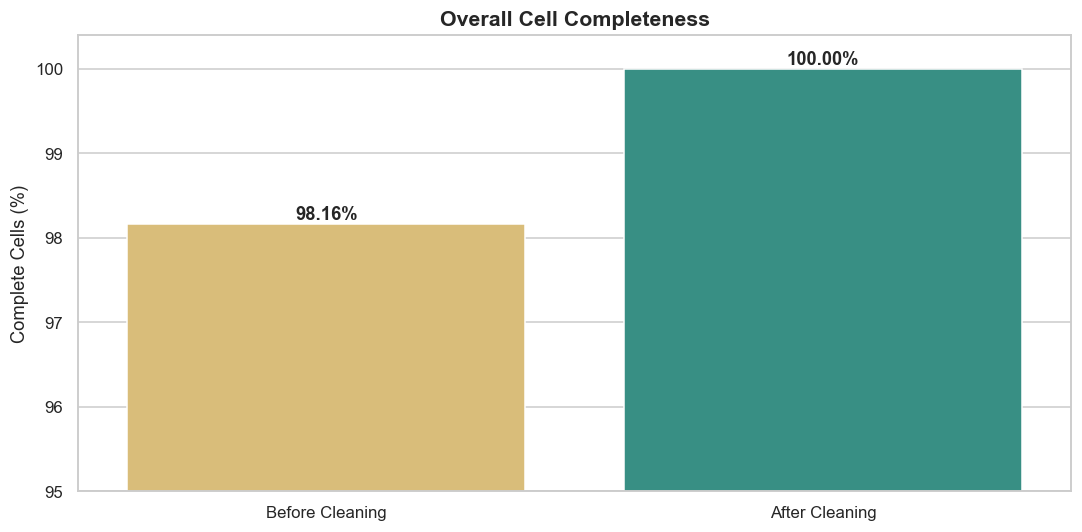

In [12]:
overall_completeness_after = 100 * clean_df.notna().sum().sum() / clean_df.size

before_after = pd.DataFrame([
    ("Records", len(raw_df), len(clean_df), rows_removed),
    ("Missing cells", total_missing_before, int(clean_df.isna().sum().sum()), -total_missing_before),
    ("Overall completeness (%)", overall_completeness_before, overall_completeness_after,
     overall_completeness_after - overall_completeness_before),
    ("Complete duplicate rows", int(raw_df.duplicated().sum()), int(clean_df.duplicated().sum()), 0),
    ("Duplicate OrderIDs", int(raw_df["OrderID"].duplicated().sum()), duplicate_ids_after, 0),
    ("Incorrectly formatted dates", invalid_dates_before, invalid_dates_after, 0),
], columns=["Metric", "Before", "After", "Change"])
display(before_after)

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Cleaning"],
    "Completeness": [overall_completeness_before, overall_completeness_after],
})
sns.barplot(data=plot_data, x="Stage", y="Completeness", hue="Stage",
            palette=[COLORS["gold"], COLORS["teal"]], legend=False, ax=ax)
ax.set_ylim(95, 100.4)
ax.set_title("Overall Cell Completeness")
ax.set_ylabel("Complete Cells (%)")
ax.set_xlabel("")
for patch in ax.patches:
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.05,
        f"{patch.get_height():.2f}%",
        ha="center",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

## 9. Missingness Evidence

The raw missingness matrix shows that blanks are confined to `CouponCode`. The cleaned matrix is
complete after the semantic replacement.

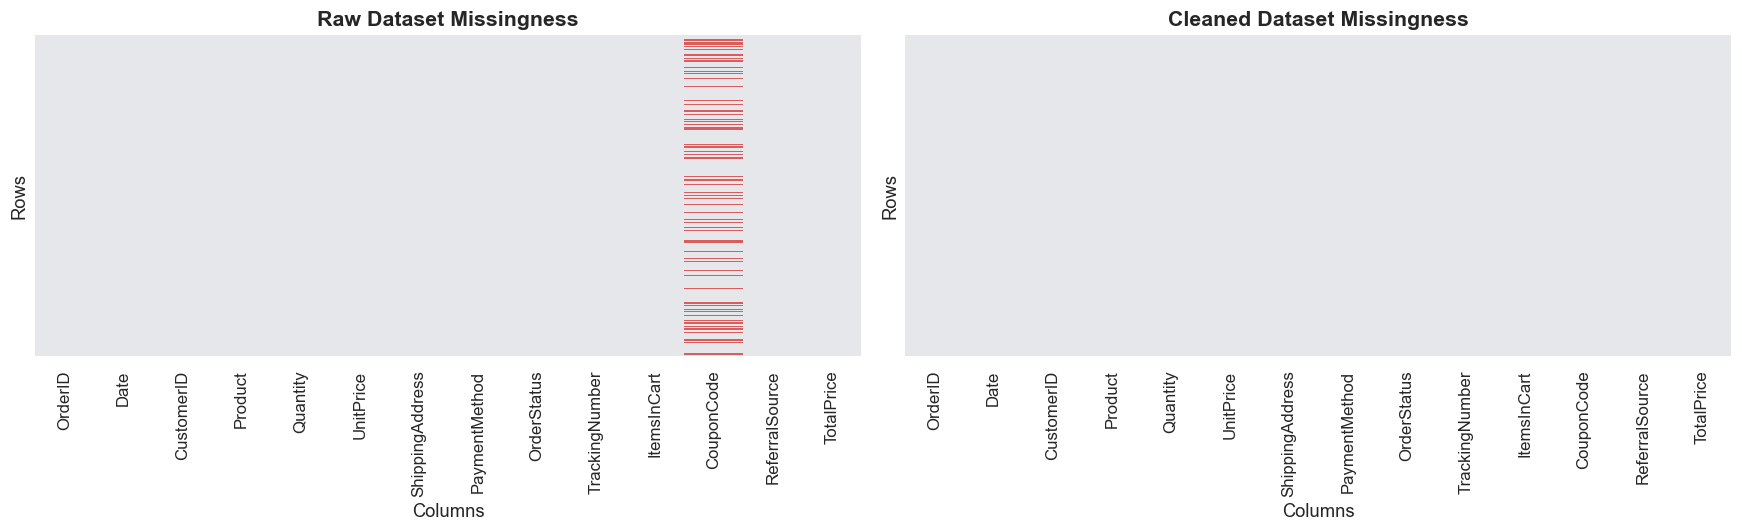

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(
    raw_df.isna(), yticklabels=False, cbar=False, cmap=["#E5E7EB", COLORS["red"]],
    ax=axes[0]
)
axes[0].set_title("Raw Dataset Missingness")
axes[0].set_xlabel("Columns")
axes[0].set_ylabel("Rows")

sns.heatmap(
    clean_df.isna(), yticklabels=False, cbar=False, cmap=["#E5E7EB", COLORS["red"]],
    ax=axes[1]
)
axes[1].set_title("Cleaned Dataset Missingness")
axes[1].set_xlabel("Columns")
axes[1].set_ylabel("Rows")
plt.tight_layout()
plt.show()

## 10. Cleaned Dataset Review

`clean_df` is the final analysis-ready dataset. Dates remain real datetime values and numeric fields
retain numeric types. This is preferable to converting dates into display-only strings.

In [14]:
print(f"Final shape: {clean_df.shape[0]:,} rows × {clean_df.shape[1]} columns")
display(clean_df.head(10))
display(clean_df.tail(5))

numeric_summary = clean_df[["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]].describe().T
display(numeric_summary)

Final shape: 1,200 rows × 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.10"
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.40"
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.04"
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NO_COUPON,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,"2,037.52"


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO_COUPON,Facebook,"1,325.06"
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,"1,050.08"
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,"2,242.32"


,count,mean,std,min,25%,50%,75%,max
Quantity,"1,200.00",2.95,1.41,1.00,2.00,3.00,4.00,5.00
UnitPrice,"1,200.00",356.41,197.18,11.39,186.06,364.21,521.57,699.93
ItemsInCart,"1,200.00",5.49,2.28,1.00,4.00,5.00,7.00,10.00
TotalPrice,"1,200.00","1,053.97",819.86,11.39,410.52,823.62,"1,578.47","3,456.40"


In [15]:
categorical_summary = pd.DataFrame({
    "Unique Values": clean_df[
        ["Product", "PaymentMethod", "OrderStatus", "CouponCode", "ReferralSource"]
    ].nunique(),
    "Most Frequent Value": clean_df[
        ["Product", "PaymentMethod", "OrderStatus", "CouponCode", "ReferralSource"]
    ].mode().iloc[0],
    "Most Frequent Count": [
        clean_df[column].value_counts().iloc[0]
        for column in ["Product", "PaymentMethod", "OrderStatus", "CouponCode", "ReferralSource"]
    ],
})
display(categorical_summary)

,Unique Values,Most Frequent Value,Most Frequent Count
Product,7,Printer,181
PaymentMethod,5,Online,258
OrderStatus,5,Cancelled,250
CouponCode,4,FREESHIP,313
ReferralSource,5,Instagram,259


## 11. Cleaning Audit Log

This audit log makes every transformation traceable and distinguishes actual corrections from
defensive standardization.

In [16]:
audit_log = pd.DataFrame([
    (
        "Missing-value treatment",
        "CouponCode",
        f"{coupon_missing_before} blanks",
        "Replaced blank values with NO_COUPON",
        f"{int(clean_df['CouponCode'].isna().sum())} blanks",
        "Applied"
    ),
    (
        "Complete-row deduplication",
        "All columns",
        f"{complete_duplicates_found} duplicates",
        "drop_duplicates()",
        f"{int(clean_df.duplicated().sum())} duplicates",
        "No records required removal"
    ),
    (
        "Business-key deduplication",
        "OrderID",
        f"{duplicate_order_ids_found} duplicates",
        "Keep first record per OrderID",
        f"{duplicate_ids_after} duplicates",
        "No records required removal"
    ),
    (
        "Date normalization",
        "Date",
        f"{invalid_dates_before} invalid",
        "Parse with errors='coerce'",
        f"{invalid_dates_after} invalid",
        "Validated"
    ),
    (
        "Identifier normalization",
        "OrderID, CustomerID, TrackingNumber",
        "Audited",
        "Trim whitespace and uppercase",
        "All patterns valid",
        "Standardized defensively"
    ),
    (
        "Category normalization",
        "Product, PaymentMethod, OrderStatus, ReferralSource",
        "Audited",
        "Trim whitespace and apply title case",
        "All values in expected sets",
        "Standardized defensively"
    ),
    (
        "Numeric normalization",
        "Quantity, ItemsInCart, UnitPrice, TotalPrice",
        "Audited",
        "Enforce numeric types and monetary precision",
        "All numeric rules pass",
        "Validated"
    ),
], columns=["Step", "Fields", "Before", "Action", "After", "Outcome"])
display(audit_log)

,Step,Fields,Before,Action,After,Outcome
0,Missing-value treatment,CouponCode,309 blanks,Replaced blank values with NO_COUPON,0 blanks,Applied
1,Complete-row deduplication,All columns,0 duplicates,drop_duplicates(),0 duplicates,No records required removal
2,Business-key deduplication,OrderID,0 duplicates,Keep first record per OrderID,0 duplicates,No records required removal
3,Date normalization,Date,0 invalid,Parse with errors='coerce',0 invalid,Validated
4,Identifier normalization,"OrderID, CustomerID, TrackingNumber",Audited,Trim whitespace and uppercase,All patterns valid,Standardized defensively
5,Category normalization,"Product, PaymentMethod, OrderStatus, ReferralS...",Audited,Trim whitespace and apply title case,All values in expected sets,Standardized defensively
6,Numeric normalization,"Quantity, ItemsInCart, UnitPrice, TotalPrice",Audited,Enforce numeric types and monetary precision,All numeric rules pass,Validated


## 12. Conclusion

The dataset is now explicitly analysis-ready:

- all 1,200 source records are retained;
- all missing coupon states are labelled `NO_COUPON`;
- no complete duplicates remain;
- no duplicate order IDs remain;
- no incorrectly formatted dates remain;
- identifiers, categories, numeric fields, and revenue arithmetic pass validation.

Most importantly, the workflow does not invent data-quality problems. The raw workbook already passed
the duplicate and date requirements; the notebook proves that fact, applies reproducible controls, and
documents the one necessary semantic treatment.